## Model Training and Evaluation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from sklearn.preprocessing import StandardScaler

## Multi-horizon setup (1-4 weeks ahead)

The project goal is to forecast 1-4 weeks ahead, not just next-week. Each horizon gets its own direct target (`target_rel_h1`-`target_rel_h4`, built in eda.ipynb) predicted from the same "as of last known week" features -- no recursive feeding of predictions back in, so error doesn't compound across horizons and the existing per-location normalization (predictions are relative to each row's `roll4` baseline) carries over unchanged.

Train/val/test seasons are unchanged from the single-horizon work: train on 2020-21/2021-22/2022-23/2023-24 (national + in-sync states for the latter two), validate on 2024-25, test on 2025-26. Each horizon drops its own rows independently (h4 loses the last 3 rows of every season; h1 loses none beyond what feature lagging already required), which is why `build_split` re-applies `dropna` per horizon instead of once up front.

In [2]:
model_df_final = pd.read_csv("data/flu_features.csv", parse_dates=["date"])
combined_df = pd.read_csv("data/flu_features_combined.csv", parse_dates=["date"])

feature_cols_final = [
    "lag1_rel",
    "lag2_rel",
    "lag3_rel",
    "lag4_rel",
    "wow_pct_lag1",
    "wow_pct_lag2",
    "roll4_cv",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    "is_onset_zone",
    "is_peak_zone",
    "covid_suppressed",
    "flu_search_index_lag1",
]

TRAIN_SEASONS = ["2020-21", "2021-22", "2022-23", "2023-24"]
VAL_SEASON = "2024-25"
TEST_SEASON = "2025-26"
HORIZONS = [1, 2, 3, 4]


def build_split(h):
    """Build a scaled train/val/test split for horizon h weeks ahead."""
    target_col = f"target_rel_h{h}"
    admissions_col = f"weekly_admissions_h{h}"
    required = feature_cols_final + [target_col]

    train = (
        combined_df[combined_df["season"].isin(TRAIN_SEASONS)]
        .dropna(subset=required)
        .copy()
    )
    val = (
        model_df_final[model_df_final["season"] == VAL_SEASON]
        .dropna(subset=required)
        .copy()
    )
    test = (
        model_df_final[model_df_final["season"] == TEST_SEASON]
        .dropna(subset=required)
        .copy()
    )

    scaler = StandardScaler()
    scaler.fit(train[feature_cols_final])

    return {
        "train": train,
        "val": val,
        "test": test,
        "X_train": scaler.transform(train[feature_cols_final]),
        "X_val": scaler.transform(val[feature_cols_final]),
        "X_test": scaler.transform(test[feature_cols_final]),
        "y_train": train[target_col].values,
        "y_val": val[target_col].values,
        "y_test": test[target_col].values,
        "train_actual": train[admissions_col].values,
        "val_actual": val[admissions_col].values,
        "test_actual": test[admissions_col].values,
    }


splits = {h: build_split(h) for h in HORIZONS}

for h in HORIZONS:
    s = splits[h]
    print(
        f"Horizon {h}: train={len(s['train']):>4} val={len(s['val']):>3} "
        f"test={len(s['test']):>3}"
    )

Horizon 1: train=2891 val= 31 test= 31
Horizon 2: train=2802 val= 30 test= 30
Horizon 3: train=2708 val= 29 test= 29
Horizon 4: train=2613 val= 28 test= 28


In [3]:
# Confirm no temporal overlap (using horizon 1's split as representative --
# all horizons share the same season boundaries, just fewer trailing rows)
train1, val1, test1 = splits[1]["train"], splits[1]["val"], splits[1]["test"]
print(f"Train ends : {train1['date'].max().date()}")
print(f"Val starts : {val1['date'].min().date()}")
print(f"Val ends   : {val1['date'].max().date()}")
print(f"Test starts: {test1['date'].min().date()}")

Train ends : 2024-05-25
Val starts : 2024-11-02
Val ends   : 2025-05-31
Test starts: 2025-11-01


In [4]:
import joblib

# Save split dataframes for reference, one per horizon
for h in HORIZONS:
    s = splits[h]
    s["train"].to_csv(f"data/train_h{h}.csv", index=False)
    s["val"].to_csv(f"data/val_h{h}.csv", index=False)
    s["test"].to_csv(f"data/test_h{h}.csv", index=False)

print("Saved: per-horizon train/val/test CSVs")

Saved: per-horizon train/val/test CSVs


### Neural network -- hyperparameter search + one model per horizon

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)


class FluForecastNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], dropout=0.3):
        super(FluForecastNet, self).__init__()

        layers = []
        in_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend(
                [
                    nn.Linear(in_dim, hidden_dim),
                    nn.ReLU(),
                    nn.BatchNorm1d(hidden_dim),
                    nn.Dropout(dropout),
                ]
            )
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [6]:
EPOCHS = 500
SEARCH_EPOCHS = 100
BATCH_SIZE = 16

# Small hyperparameter grid -- kept intentionally small since MLP training is
# the most expensive part of this pipeline and it's repeated per horizon.
# Configs are ranked with a shorter search run (SEARCH_EPOCHS), then the
# winning config per horizon is retrained for the full EPOCHS budget.
mlp_param_grid = [
    {"hidden_dims": [64, 32], "dropout": 0.3, "lr": 5e-4},
    {"hidden_dims": [32, 16], "dropout": 0.2, "lr": 5e-4},
    {"hidden_dims": [128, 64], "dropout": 0.4, "lr": 5e-4},
    {"hidden_dims": [64, 32], "dropout": 0.3, "lr": 1e-3},
]


def train_mlp(X_train, y_train, X_val, y_val, params, epochs):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

    model = FluForecastNet(
        input_dim=len(feature_cols_final),
        hidden_dims=params["hidden_dims"],
        dropout=params["dropout"],
    )
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=15
    )
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True
    )

    best_val_loss = float("inf")
    best_state = None
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            # Clip gradients -- prevents exploding gradients at peak weeks
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict().copy()
        scheduler.step(val_loss)

    model.load_state_dict(best_state)
    return model, best_val_loss


mlp_results = {}
mlp_best_params = {}

for h in HORIZONS:
    s = splits[h]

    # Rank configs with a shorter search run
    search_scores = [
        train_mlp(s["X_train"], s["y_train"], s["X_val"], s["y_val"], params, SEARCH_EPOCHS)[1]
        for params in mlp_param_grid
    ]
    best_params = mlp_param_grid[int(np.argmin(search_scores))]
    mlp_best_params[h] = best_params

    # Retrain the winning config for the full epoch budget
    model, best_val_loss = train_mlp(
        s["X_train"], s["y_train"], s["X_val"], s["y_val"], best_params, EPOCHS
    )
    model.eval()
    with torch.no_grad():
        X_train_t = torch.tensor(s["X_train"], dtype=torch.float32)
        X_val_t = torch.tensor(s["X_val"], dtype=torch.float32)
        X_test_t = torch.tensor(s["X_test"], dtype=torch.float32)
        train_pred_rel = model(X_train_t).numpy().flatten()
        val_pred_rel = model(X_val_t).numpy().flatten()
        test_pred_rel = model(X_test_t).numpy().flatten()

    # Add each row's own rolling baseline back before reversing the log
    # transform -- predictions are relative to roll4 (see eda.ipynb
    # normalization), so admissions = expm1(pred_rel + log1p(roll4))
    mlp_results[h] = {
        "train_preds": np.expm1(train_pred_rel + np.log1p(s["train"]["roll4"].values)),
        "val_preds": np.expm1(val_pred_rel + np.log1p(s["val"]["roll4"].values)),
        "test_preds": np.expm1(test_pred_rel + np.log1p(s["test"]["roll4"].values)),
        "best_val_loss": best_val_loss,
    }
    print(f"Horizon {h}: best config={best_params}, val loss={best_val_loss:.4f}")

Horizon 1: best config={'hidden_dims': [64, 32], 'dropout': 0.3, 'lr': 0.001}, val loss=0.0509
Horizon 2: best config={'hidden_dims': [64, 32], 'dropout': 0.3, 'lr': 0.001}, val loss=0.1418
Horizon 3: best config={'hidden_dims': [32, 16], 'dropout': 0.2, 'lr': 0.0005}, val loss=0.2553
Horizon 4: best config={'hidden_dims': [64, 32], 'dropout': 0.3, 'lr': 0.001}, val loss=0.3642


### XGBoost, LightGBM, Ridge -- hyperparameter search + one model per horizon

In [7]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge

# Small grids, selected by validation-set MAE on the actual admissions scale
# (not k-fold CV, which would shuffle across the temporal train/val boundary
# we've deliberately preserved throughout this project)
xgb_lgbm_param_grid = [
    {"max_depth": d, "learning_rate": lr}
    for d in [2, 3, 4]
    for lr in [0.03, 0.05, 0.1]
]
# Wide range on Ridge's alpha -- an earlier narrower grid (up to 100) picked
# 100 at every horizon, meaning the true optimum was off the edge of the
# grid. This range finds an interior optimum instead (typically 300-1000).
ridge_alpha_grid = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0]


def val_mae(model, X_val, val_actual, roll4_val_log):
    preds = np.expm1(model.predict(X_val) + roll4_val_log)
    return np.abs(val_actual - preds).mean()


tree_results = {}
tree_best_params = {}

for h in HORIZONS:
    s = splits[h]
    roll4_train_log = np.log1p(s["train"]["roll4"].values)
    roll4_val_log = np.log1p(s["val"]["roll4"].values)
    roll4_test_log = np.log1p(s["test"]["roll4"].values)
    val_actual = s["val_actual"]

    # --- XGBoost: grid search over depth / learning rate ---
    best_xgb, best_xgb_mae, best_xgb_params = None, np.inf, None
    for params in xgb_lgbm_param_grid:
        m = XGBRegressor(
            n_estimators=200,
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,  # L1 regularization
            reg_lambda=1.0,  # L2 regularization
            random_state=42,
        )
        m.fit(
            s["X_train"], s["y_train"], eval_set=[(s["X_val"], s["y_val"])], verbose=False
        )
        mae = val_mae(m, s["X_val"], val_actual, roll4_val_log)
        if mae < best_xgb_mae:
            best_xgb, best_xgb_mae, best_xgb_params = m, mae, params

    # --- LightGBM: same grid ---
    best_lgbm, best_lgbm_mae, best_lgbm_params = None, np.inf, None
    for params in xgb_lgbm_param_grid:
        m = LGBMRegressor(
            n_estimators=200,
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            min_child_samples=5,
            random_state=42,
            verbose=-1,
        )
        m.fit(s["X_train"], s["y_train"], eval_set=[(s["X_val"], s["y_val"])])
        mae = val_mae(m, s["X_val"], val_actual, roll4_val_log)
        if mae < best_lgbm_mae:
            best_lgbm, best_lgbm_mae, best_lgbm_params = m, mae, params

    # --- Ridge: alpha sweep ---
    best_ridge, best_ridge_mae, best_ridge_alpha = None, np.inf, None
    for alpha in ridge_alpha_grid:
        m = Ridge(alpha=alpha)
        m.fit(s["X_train"], s["y_train"])
        mae = val_mae(m, s["X_val"], val_actual, roll4_val_log)
        if mae < best_ridge_mae:
            best_ridge, best_ridge_mae, best_ridge_alpha = m, mae, alpha

    tree_results[h] = {
        "xgb_train": np.expm1(best_xgb.predict(s["X_train"]) + roll4_train_log),
        "xgb_val": np.expm1(best_xgb.predict(s["X_val"]) + roll4_val_log),
        "xgb_test": np.expm1(best_xgb.predict(s["X_test"]) + roll4_test_log),
        "lgbm_train": np.expm1(best_lgbm.predict(s["X_train"]) + roll4_train_log),
        "lgbm_val": np.expm1(best_lgbm.predict(s["X_val"]) + roll4_val_log),
        "lgbm_test": np.expm1(best_lgbm.predict(s["X_test"]) + roll4_test_log),
        "ridge_train": np.expm1(best_ridge.predict(s["X_train"]) + roll4_train_log),
        "ridge_val": np.expm1(best_ridge.predict(s["X_val"]) + roll4_val_log),
        "ridge_test": np.expm1(best_ridge.predict(s["X_test"]) + roll4_test_log),
    }
    tree_best_params[h] = {
        "xgb": best_xgb_params,
        "lgbm": best_lgbm_params,
        "ridge_alpha": best_ridge_alpha,
    }
    print(
        f"Horizon {h}: xgb={best_xgb_params}, lgbm={best_lgbm_params}, "
        f"ridge_alpha={best_ridge_alpha}"
    )

/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/

Horizon 1: xgb={'max_depth': 4, 'learning_rate': 0.05}, lgbm={'max_depth': 2, 'learning_rate': 0.03}, ridge_alpha=1000.0


/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/

Horizon 2: xgb={'max_depth': 2, 'learning_rate': 0.03}, lgbm={'max_depth': 2, 'learning_rate': 0.03}, ridge_alpha=300.0


/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/

Horizon 3: xgb={'max_depth': 2, 'learning_rate': 0.03}, lgbm={'max_depth': 2, 'learning_rate': 0.03}, ridge_alpha=1000.0


/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/

Horizon 4: xgb={'max_depth': 2, 'learning_rate': 0.03}, lgbm={'max_depth': 2, 'learning_rate': 0.03}, ridge_alpha=1000.0


/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/pius/Projects/analytics-engineering/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Multi-horizon evaluation summary

In [8]:
def evaluate(actual, predicted):
    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-8))) * 100
    return mae, rmse, mape


print("=" * 92)
print("MULTI-HORIZON EVALUATION SUMMARY (MAE)")
print("=" * 92)
print(f"{'Horizon':<10}{'Model':<20}{'Train MAE':>14}{'Val MAE':>14}{'Test MAE':>14}")
print("-" * 92)

summary_rows = []
for h in HORIZONS:
    s = splits[h]
    train_actual = s["train_actual"]
    val_actual = s["val_actual"]
    test_actual = s["test_actual"]

    model_preds = {
        "MLP (Neural Net)": (
            mlp_results[h]["train_preds"],
            mlp_results[h]["val_preds"],
            mlp_results[h]["test_preds"],
        ),
        "XGBoost": (
            tree_results[h]["xgb_train"],
            tree_results[h]["xgb_val"],
            tree_results[h]["xgb_test"],
        ),
        "LightGBM": (
            tree_results[h]["lgbm_train"],
            tree_results[h]["lgbm_val"],
            tree_results[h]["lgbm_test"],
        ),
        "Ridge": (
            tree_results[h]["ridge_train"],
            tree_results[h]["ridge_val"],
            tree_results[h]["ridge_test"],
        ),
        "Rolling Mean": (
            s["train"]["roll4"].values,
            s["val"]["roll4"].values,
            s["test"]["roll4"].values,
        ),
    }

    for model_name, (train_pred, val_pred, test_pred) in model_preds.items():
        train_mae, _, _ = evaluate(train_actual, train_pred)
        val_mae, _, _ = evaluate(val_actual, val_pred)
        test_mae, _, _ = evaluate(test_actual, test_pred)
        summary_rows.append(
            {
                "horizon": h,
                "model": model_name,
                "train_mae": train_mae,
                "val_mae": val_mae,
                "test_mae": test_mae,
            }
        )
        print(f"{h:<10}{model_name:<20}{train_mae:>14,.0f}{val_mae:>14,.0f}{test_mae:>14,.0f}")
    print("-" * 92)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("data/multi_horizon_summary.csv", index=False)

MULTI-HORIZON EVALUATION SUMMARY (MAE)
Horizon   Model                    Train MAE       Val MAE      Test MAE
--------------------------------------------------------------------------------------------
1         MLP (Neural Net)                37         4,605         2,702
1         XGBoost                         37         4,064         1,855
1         LightGBM                        52         4,220         1,903
1         Ridge                           65         3,653         2,405
1         Rolling Mean                   144         7,959         5,364
--------------------------------------------------------------------------------------------
2         MLP (Neural Net)                59         9,628         4,889
2         XGBoost                         79         7,304         3,692
2         LightGBM                        75         8,113         3,646
2         Ridge                           99         5,390         3,781
2         Rolling Mean                   194 

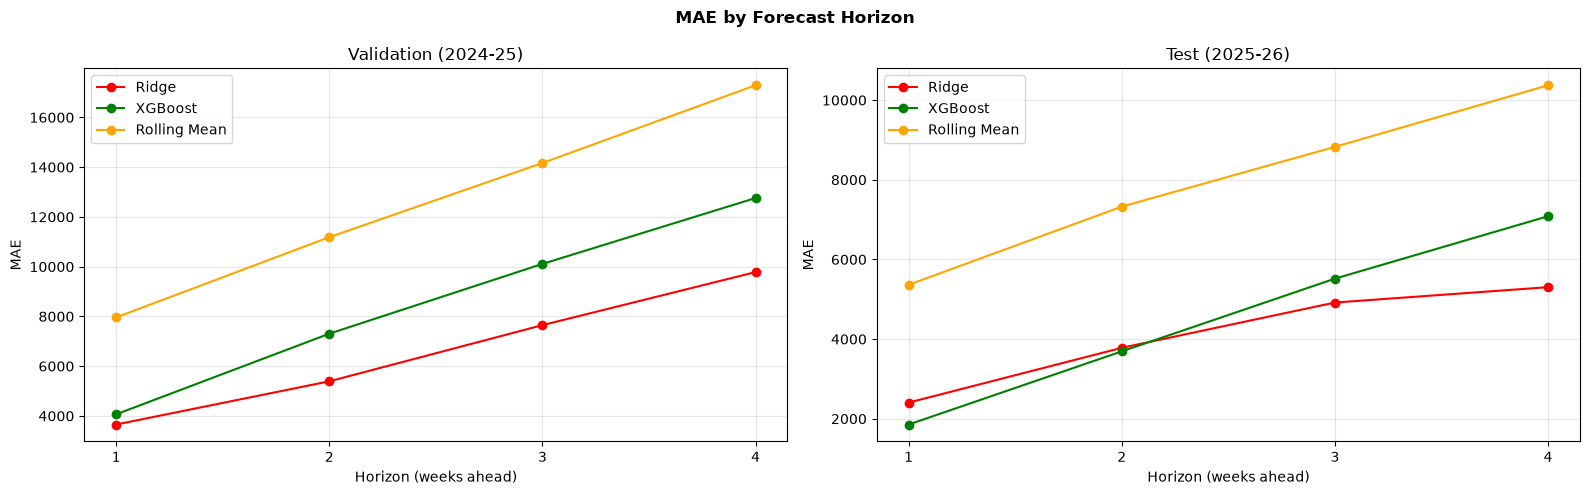

In [9]:
# Ridge MAE by horizon vs. the rolling-mean baseline -- does the model's edge
# over the baseline hold up as the forecast reaches further into the future?
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, split_col, title in [
    (axes[0], "val_mae", "Validation (2024-25)"),
    (axes[1], "test_mae", "Test (2025-26)"),
]:
    for model_name, color in [
        ("Ridge", "red"),
        ("XGBoost", "green"),
        ("Rolling Mean", "orange"),
    ]:
        sub = summary_df[summary_df["model"] == model_name]
        ax.plot(
            sub["horizon"], sub[split_col], marker="o", label=model_name, color=color
        )
    ax.set_title(title)
    ax.set_xlabel("Horizon (weeks ahead)")
    ax.set_ylabel("MAE")
    ax.set_xticks(HORIZONS)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("MAE by Forecast Horizon", fontweight="bold")
plt.tight_layout()
plt.show()

**Reading the train/val/test comparison below:** train MAE is not directly comparable to val/test MAE here, and a large gap between them is *not* primarily an overfitting signal. Training data pools national rows together with state-level rows (state admissions run roughly an order of magnitude smaller than the national aggregate), while val/test are national-only. This is visible even in the unfitted Rolling Mean baseline -- it can't overfit anything, yet its own train MAE (~150-285) is tiny next to its val/test MAE (~5,000-17,000), purely because train mixes in many small-magnitude state rows. The plot below uses a log y-axis so all three bars stay legible; read the *shape* (does each model's test MAE still beat the dashed baseline line, and how does that gap change with horizon) rather than the raw train-vs-test ratio.

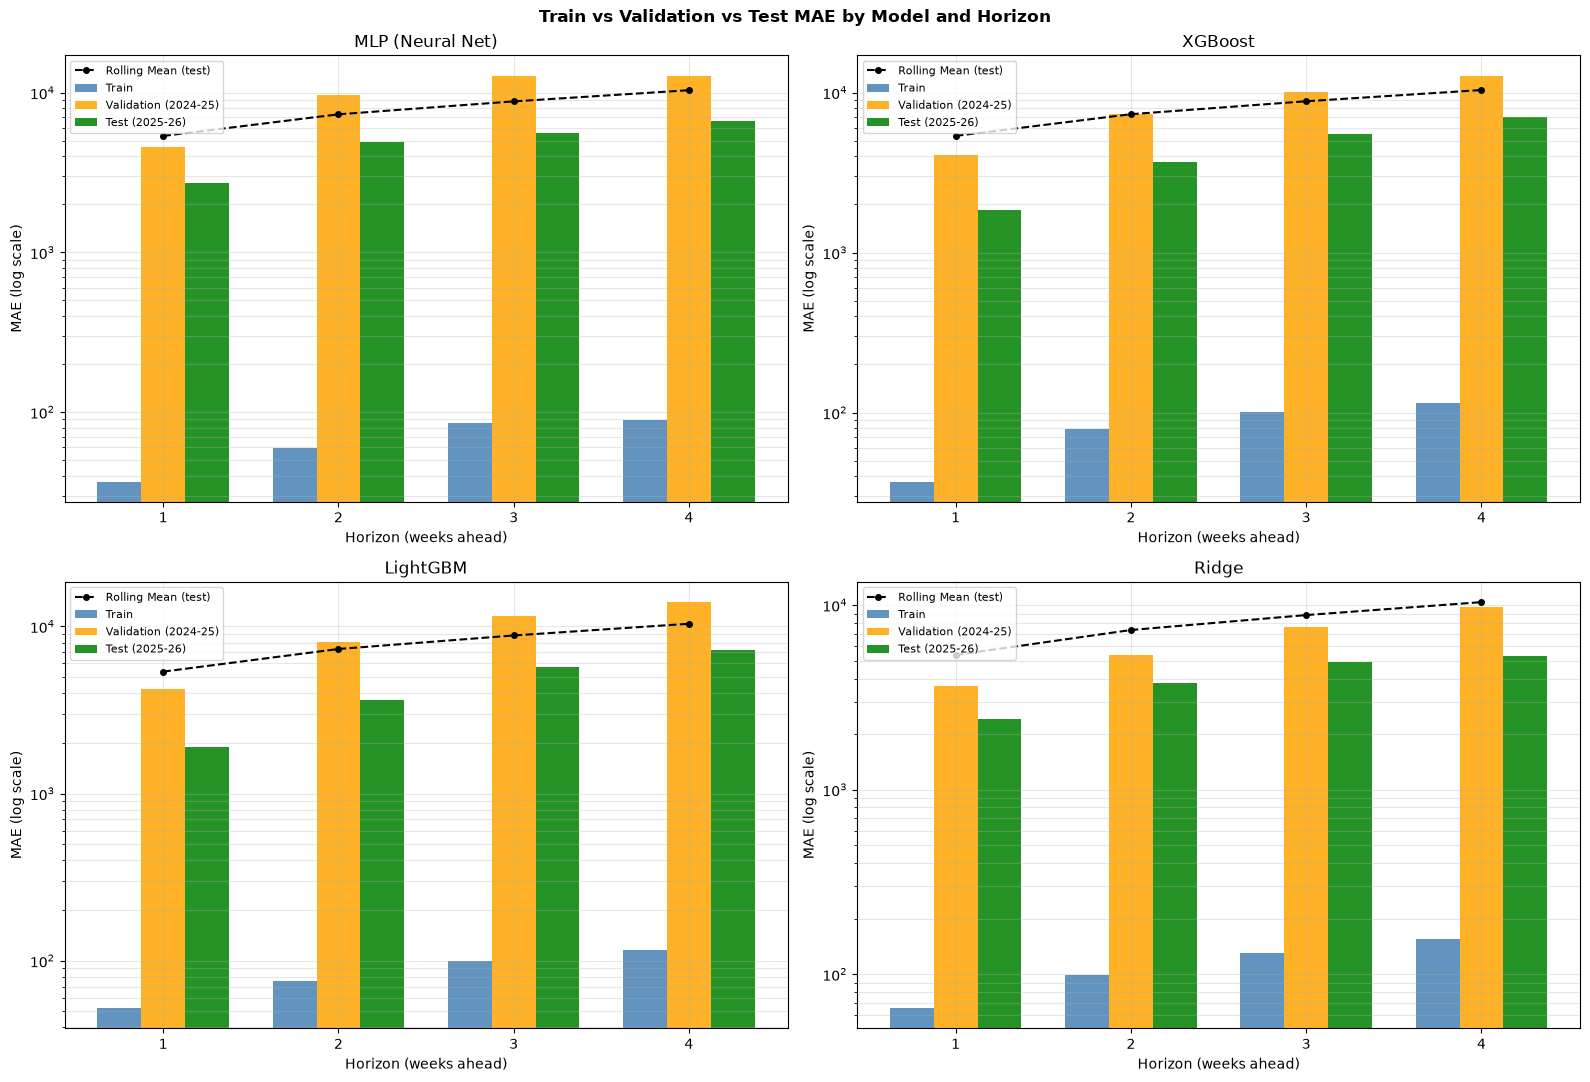

In [10]:
# Train vs Val vs Test MAE, one panel per model. Log y-axis -- train and
# val/test differ by ~1-2 orders of magnitude because train pools in
# state-level rows (see markdown above), not primarily because of overfitting
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

model_names = ["MLP (Neural Net)", "XGBoost", "LightGBM", "Ridge"]
split_colors = {"train_mae": "steelblue", "val_mae": "orange", "test_mae": "green"}
split_labels = {"train_mae": "Train", "val_mae": "Validation (2024-25)", "test_mae": "Test (2025-26)"}

baseline = summary_df[summary_df["model"] == "Rolling Mean"].set_index("horizon")

for ax, model_name in zip(axes.flatten(), model_names):
    sub = summary_df[summary_df["model"] == model_name].set_index("horizon")

    width = 0.25
    x = np.array(HORIZONS)
    for i, split_col in enumerate(["train_mae", "val_mae", "test_mae"]):
        ax.bar(
            x + (i - 1) * width,
            sub.loc[HORIZONS, split_col],
            width,
            label=split_labels[split_col],
            color=split_colors[split_col],
            alpha=0.85,
        )

    ax.plot(
        x,
        baseline.loc[HORIZONS, "test_mae"],
        color="black",
        ls="--",
        marker="o",
        ms=4,
        lw=1.5,
        label="Rolling Mean (test)",
    )

    ax.set_yscale("log")
    ax.set_title(model_name)
    ax.set_xlabel("Horizon (weeks ahead)")
    ax.set_ylabel("MAE (log scale)")
    ax.set_xticks(HORIZONS)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which="both")

plt.suptitle("Train vs Validation vs Test MAE by Model and Horizon", fontweight="bold")
plt.tight_layout()
plt.show()

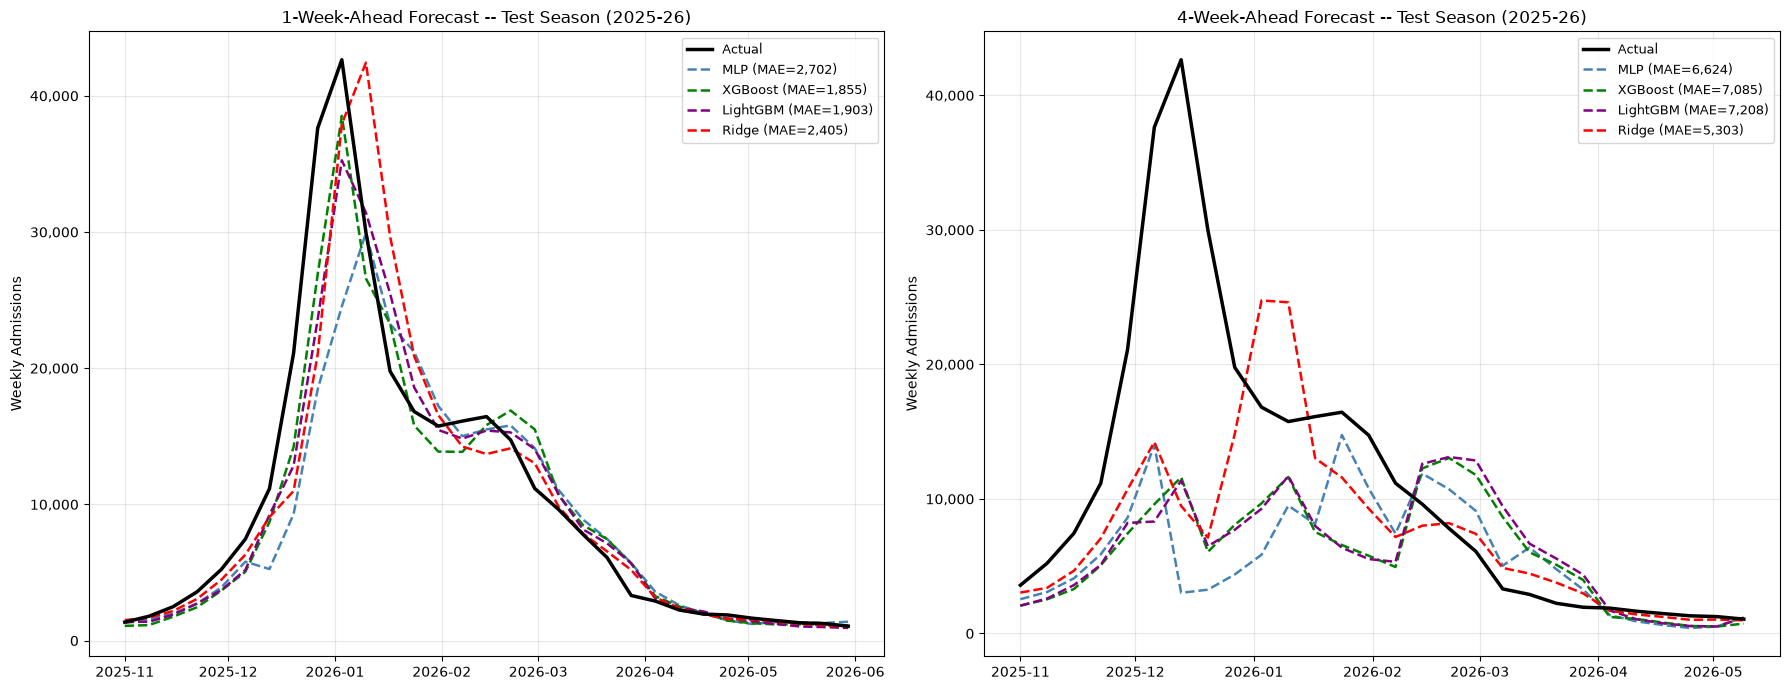

In [11]:
# All models' predictions vs actual, horizon 1 vs horizon 4, on the test
# season -- visualizes how much a 4-week-ahead forecast degrades vs. next-week,
# and how the models compare to each other at each horizon
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

model_colors = {
    "MLP": "steelblue",
    "XGBoost": "green",
    "LightGBM": "purple",
    "Ridge": "red",
}

for ax, h in zip(axes, [1, 4]):
    s = splits[h]
    test_df = s["test"].sort_values("date").reset_index(drop=True)
    test_actual = s["test_actual"]

    ax.plot(
        test_df["date"], test_actual, color="black", lw=2.5, label="Actual", zorder=5
    )

    model_preds = {
        "MLP": mlp_results[h]["test_preds"],
        "XGBoost": tree_results[h]["xgb_test"],
        "LightGBM": tree_results[h]["lgbm_test"],
        "Ridge": tree_results[h]["ridge_test"],
    }
    for model_name, preds in model_preds.items():
        mae = np.abs(test_actual - preds).mean()
        ax.plot(
            test_df["date"],
            preds,
            color=model_colors[model_name],
            lw=1.8,
            ls="--",
            label=f"{model_name} (MAE={mae:,.0f})",
        )

    ax.set_title(f"{h}-Week-Ahead Forecast -- Test Season (2025-26)")
    ax.set_ylabel("Weekly Admissions")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Final Summary

**Best model by horizon (Test MAE):**

| Horizon | Best model | Val MAE | Test MAE | vs. rolling-mean baseline |
|---|---|---|---|---|
| 1 week  | XGBoost | 4,064 | **1,855** | 5,364 |
| 2 weeks | Ridge   | 5,390 | **3,781** | 7,326 |
| 3 weeks | Ridge   | 7,648 | **4,918** | 8,827 |
| 4 weeks | Ridge   | 9,780 | **5,303** | 10,372 |

**Every model beats the rolling-mean baseline at every horizon**, and error grows with horizon for all of them as the core deliverable (1-4 week forecasting, not just next-week) is met.

**Per-location normalization was the unlock for pooling in state-level data.** The first attempt at combining national + state training rows (raw `log1p(admissions)` scale) made every model worse, because state admissions are roughly an order of magnitude smaller than the national aggregate. Re-expressing lag features and the target relative to each row's own 4-week rolling baseline (`roll4`) fixed this asthe retest showed MLP/XGBoost/LightGBM all improving substantially once state rows were on a comparable scale.

**XGBoost overtakes Ridge specifically at 1-week-ahead** once hyperparameters were tuned (depth/learning-rate grid, selected by validation MAE). At every other horizon, Ridge remains best as a simpler model generalizes better the further out the forecast reaches, likely because training-set size doesn't grow with horizon while the harder problem does.

**Ridge's regularization strength (`alpha`) needed a wider search than initially given.** The first grid (up to 100) picked the boundary value at every horizon, a clear sign the grid was too narrow. Widening it to 10,000 found the true interior optimum (300-1,000).

**The train/val/test comparison above is not a clean overfitting readout.** Train MAE looks tiny (40-155) next to val/test (thousands) at every horizon, but that gap is mostly a scale artifact where train pools in state-level rows that run an order of magnitude smaller than the national aggregate val/test use, and even the unfitted rolling-mean baseline shows the same pattern. The more informative read from that chart is that every model's test-season bar still clears the dashed baseline line at every horizon.

**Where this leaves the project's original question** ("can a deep learning model improve on existing approaches?"): not on this dataset, at this scale. 

The MLP never wins at any horizon as XGBoost and Ridge consistently outperform it, most likely because a few thousand training rows (even after pooling in state-level and pre-NHSN data) is not enough for a neural net's extra capacity to pay off over a well-regularized linear model or shallow trees.